In [2]:
!pip3 install gliner


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [3]:
import pandas as pd

df = pd.read_csv("data/products.csv")
df

,category,name,price_value,quantity,dietary
0,fruits-vegetables,France Legend Apple,5.90,700g,NaN
1,fruits-vegetables,Holland Potato (China),1.40,1kg,NaN
2,fruits-vegetables,Malaysia Natural Fresh Japanese Cucumber,1.80,400g,NaN
3,fruits-vegetables,Fresh Blueberries,3.95,125g,NaN
4,fruits-vegetables,Chef Red Onion - Large,1.70,700g,NaN
...,...,...,...,...,...
4678,frozen,Hego Lamb Shabu Shabu,13.90,300 G,NaN
4679,frozen,Kee Song Frozen CaroGold Chicken Wing,12.91,500 G,NaN
4680,frozen,Blue Oceans Boontong Fish (Whole Clean 8-10),12.00,1 KG,NaN
4681,frozen,Royal Delights Curry Potato Samosa,11.00,1.2 KG,NaN


In [4]:
def normalize_row(row):
    q = row.get('quantity')
    # isinstance guards the blank cells: a missing quantity reads as float nan,
    # which is truthy, so a plain `if q:` would try to lower() a float.
    if isinstance(q, str) and q:
        row['quantity'] = q.replace(" ", "").lower()
    return row


In [5]:
df = df.apply(normalize_row, axis=1)
df

,category,name,price_value,quantity,dietary
0,fruits-vegetables,France Legend Apple,5.90,700g,NaN
1,fruits-vegetables,Holland Potato (China),1.40,1kg,NaN
2,fruits-vegetables,Malaysia Natural Fresh Japanese Cucumber,1.80,400g,NaN
3,fruits-vegetables,Fresh Blueberries,3.95,125g,NaN
4,fruits-vegetables,Chef Red Onion - Large,1.70,700g,NaN
...,...,...,...,...,...
4678,frozen,Hego Lamb Shabu Shabu,13.90,300g,NaN
4679,frozen,Kee Song Frozen CaroGold Chicken Wing,12.91,500g,NaN
4680,frozen,Blue Oceans Boontong Fish (Whole Clean 8-10),12.00,1kg,NaN
4681,frozen,Royal Delights Curry Potato Samosa,11.00,1.2kg,NaN


In [6]:
from gliner import GLiNER

model = GLiNER.from_pretrained("urchade/gliner_large-v2.1")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
def get_entities(text, labels):
    result = model.predict_entities(
        text,
        labels,
        threshold=0.3,
    )

    return result

In [8]:
labels = ["origin", "brand", "variant", "product"]

In [9]:
import re

COUNTRIES = {
    "australia": "Australia", "malaysia": "Malaysia", "thailand": "Thailand", "japan": "Japan",
    "china": "China", "korea": "South Korea", "south korea": "South Korea", "taiwan": "Taiwan",
    "vietnam": "Vietnam", "indonesia": "Indonesia", "india": "India", "philippines": "Philippines",
    "singapore": "Singapore", "sg local": "Singapore", "hong kong": "Hong Kong",
    "new zealand": "New Zealand", "usa": "USA", "united states": "USA", "america": "USA",
    "canada": "Canada", "mexico": "Mexico", "peru": "Peru", "chile": "Chile",
    "argentina": "Argentina", "brazil": "Brazil", "ecuador": "Ecuador", "egypt": "Egypt",
    "turkey": "Turkey", "france": "France", "holland": "Netherlands", "netherlands": "Netherlands",
    "italy": "Italy", "spain": "Spain", "germany": "Germany", "denmark": "Denmark",
    "norway": "Norway", "sweden": "Sweden", "iceland": "Iceland", "ireland": "Ireland",
    "scotland": "Scotland", "england": "England", "greece": "Greece", "switzerland": "Switzerland",
    "belgium": "Belgium", "portugal": "Portugal", "poland": "Poland", "russia": "Russia",
    "pakistan": "Pakistan", "myanmar": "Myanmar", "cambodia": "Cambodia", "lebanon": "Lebanon",
    "sri lanka": "Sri Lanka", "kenya": "Kenya", "south africa": "South Africa", "morocco": "Morocco",
}

DEMONYMS = {
    "malaysian": "Malaysia", "australian": "Australia", "norwegian": "Norway", "chilean": "Chile",
    "peruvian": "Peru", "icelandic": "Iceland", "canadian": "Canada", "taiwanese": "Taiwan",
    "vietnamese": "Vietnam", "indonesian": "Indonesia", "indian": "India",
    "korean": "South Korea", "filipino": "Philippines", "japanese": "Japan", "thai": "Thailand",
    "chinese": "China", "greek": "Greece", "french": "France", "italian": "Italy",
    "spanish": "Spain", "german": "Germany", "swiss": "Switzerland", "belgian": "Belgium",
    "danish": "Denmark", "dutch": "Netherlands", "english": "England", "british": "England",
    "scottish": "Scotland", "irish": "Ireland", "american": "USA", "mexican": "Mexico",
    "turkish": "Turkey", "portuguese": "Portugal", "russian": "Russia", "polish": "Poland",
    "swedish": "Sweden", "brazilian": "Brazil", "argentinian": "Argentina",
    "moroccan": "Morocco", "egyptian": "Egypt", "lebanese": "Lebanon",
}

GEO = {**COUNTRIES, **DEMONYMS}

def _pattern(keys):
    # longest first, so "new zealand" wins over a bare "zealand" fragment
    alts = "|".join(sorted(map(re.escape, keys), key=len, reverse=True))
    return re.compile(rf"\b({alts})\b", re.I)

ANY, COUNTRY_ONLY = _pattern(GEO), _pattern(COUNTRIES)
US = re.compile(r"\bU\.?S\.?\b")  # case-sensitive: the pronoun "us" is not a country
MEAT = re.compile(r"\b(ham|breast|sausage|bacon|slice[ds]?|mince[ds]?|roll|frank\w*|deli"
                  r"|drumstick|wing|smoked)\b", re.I)
STYLE = re.compile(r"\b(style|bbq|kimchi|marinated|flavou?r\w*|recipe|seasoning|sauce)\b", re.I)

def find_country(name):
    """(canonical country, the text that matched) for one product name."""
    name = str(name)
    # "Korean Style Fish Cake" names a recipe, so in those rows only the noun forms count.
    pattern = COUNTRY_ONLY if STYLE.search(name) else ANY
    if MEAT.search(name):
        name = re.sub(r"\bturkey\b", " ", name, flags=re.I)  # the bird, not the country
    inside = " ".join(re.findall(r"\(([^)]*)\)", name))
    for text in (inside, name):  # a parenthesised country is the origin marker
        m = pattern.search(text)
        if m:
            return GEO[m.group(1).lower()], m.group(1)
    m = US.search(name)
    return ("USA", m.group(0)) if m else ("", "")

def drop_surface(text, surface):
    """Remove the country the row already matched, so it cannot land in another column."""
    if not surface:
        return text
    out = re.sub(rf"\b{re.escape(surface)}\b", " ", text, flags=re.I)
    out = re.sub(r"\(\s*\)|\[\s*\]", " ", out)
    return re.sub(r"\s{2,}", " ", out).strip(" -")

df["origin"] = df["name"].map(lambda n: find_country(n)[0])
df["origin"].value_counts()

origin
                3965
Japan            101
Australia         97
Malaysia          88
Thailand          70
China             44
Greece            38
USA               28
France            27
Italy             27
New Zealand       25
Singapore         24
Taiwan            18
India             13
South Korea       13
Spain              9
Switzerland        8
Norway             8
Indonesia          8
Mexico             7
Germany            7
Hong Kong          6
South Africa       6
Chile              6
Canada             5
Ireland            4
Scotland           4
Belgium            4
England            4
Vietnam            3
Netherlands        3
Denmark            3
Lebanon            2
Egypt              2
Turkey             2
Pakistan           1
Argentina          1
Philippines        1
Peru               1
Name: count, dtype: int64

In [10]:
from tqdm.auto import tqdm

NER_LABELS = [l for l in labels if l != "origin"]  # origin already came from the country list

def build_text(name, category):
    # The category is another signal context for the NER
    prefix = f"Supermarket {str(category).replace('-', ' ')} item: "
    return prefix + str(name), len(prefix)

def best_entity(entities, labels, offset, surface):
    best = {}
    for e in entities:
        if e["start"] < offset:
            continue
        if e["score"] > best.get(e["label"], {"score": -1.0})["score"]:
            best[e["label"]] = e
    # The model folds the country into the brand ("Pasar Australia"), so strip the
    # span this row already matched as its origin.
    return [drop_surface(best[l]["text"], surface) if l in best else "" for l in labels]

def add_entity_columns(
    df, labels, threshold=0.3, batch_size=32
):
    products_dict = {}
    names = df["name"].fillna("")
    built = [
        build_text(n, c) for n, c in zip(names, df["category"].fillna(""))
    ]
    surfaces = [find_country(n)[1] for n in names]
    rows = []

    for i in tqdm(range(0, len(built), batch_size), desc="tagging"):
        chunk, found = built[i : i + batch_size], surfaces[i : i + batch_size]
        preds = model.inference(
            [t for t, _ in chunk],
            labels,
            threshold=threshold,
            batch_size=batch_size,
            flat_ner=True,
            multi_label=True,
        )
        rows += [
            best_entity(p, labels, off, s)
            for p, (_, off), s in zip(preds, chunk, found)
        ]

    # Assign extracted entity columns
    df[labels] = pd.DataFrame(rows, index=df.index, columns=labels)

    # Collect target entity fields per row
    target_fields = ["origin", "brand", "variant", "price_value"]
    available_fields = [col for col in target_fields if col in df.columns]

    if "product" in df.columns:
        for prod_name, entity_data in zip(
            df["product"].astype(str), df[available_fields].to_dict("records")
        ):
            products_dict.setdefault(prod_name, []).append(entity_data)

    return df, products_dict

df, products = add_entity_columns(df, NER_LABELS)
df

tagging:   0%|          | 0/147 [00:00<?, ?it/s]

,category,name,price_value,quantity,dietary,origin,brand,variant,product
0,fruits-vegetables,France Legend Apple,5.90,700g,NaN,France,Legend,Legend,Apple
1,fruits-vegetables,Holland Potato (China),1.40,1kg,NaN,China,,,Holland Potato
2,fruits-vegetables,Malaysia Natural Fresh Japanese Cucumber,1.80,400g,NaN,Malaysia,Natural Fresh,Natural Fresh,Japanese Cucumber
3,fruits-vegetables,Fresh Blueberries,3.95,125g,NaN,,,Fresh Blueberries,
4,fruits-vegetables,Chef Red Onion - Large,1.70,700g,NaN,,Chef,Large,Red Onion
...,...,...,...,...,...,...,...,...,...
4678,frozen,Hego Lamb Shabu Shabu,13.90,300g,NaN,,Hego Lamb,Shabu Shabu,
4679,frozen,Kee Song Frozen CaroGold Chicken Wing,12.91,500g,NaN,,Kee Song,CaroGold,Chicken Wing
4680,frozen,Blue Oceans Boontong Fish (Whole Clean 8-10),12.00,1kg,NaN,,Blue Oceans,Whole Clean 8-10,Boontong Fish
4681,frozen,Royal Delights Curry Potato Samosa,11.00,1.2kg,NaN,,Royal Delights,Curry Potato Samosa,Curry Potato Samosa


In [11]:
products

{'Apple': [{'origin': 'France',
   'brand': 'Legend',
   'variant': 'Legend',
   'price_value': 5.9},
  {'origin': 'China', 'brand': '', 'variant': '', 'price_value': 4.85},
  {'origin': '', 'brand': 'Enza', 'variant': 'Envy', 'price_value': 6.45},
  {'origin': 'Italy', 'brand': 'Joya', 'variant': '', 'price_value': 2.95},
  {'origin': 'China',
   'brand': 'YayaPapaya',
   'variant': 'Red',
   'price_value': 3.4},
  {'origin': '',
   'brand': 'YayaPapaya',
   'variant': 'Envy',
   'price_value': 6.95},
  {'origin': 'China',
   'brand': 'YayaPapaya',
   'variant': 'Red Fuji',
   'price_value': 72.0},
  {'origin': '',
   'brand': 'ZENXIN',
   'variant': 'Organic Queen',
   'price_value': 5.95}],
 'Holland Potato': [{'origin': 'China',
   'brand': '',
   'variant': '',
   'price_value': 1.4}],
 'Japanese Cucumber': [{'origin': 'Malaysia',
   'brand': 'Natural Fresh',
   'variant': 'Natural Fresh',
   'price_value': 1.8}],
 '': [{'origin': '',
   'brand': '',
   'variant': 'Fresh Blueberri

In [12]:
df.to_csv("data/products_prices_fairprice.csv")

**Price mapping**

In [13]:
price_df = df
nutrient_df = pd.read_csv("data/food_nutrients.csv")

In [14]:
import ast
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# stopword, normalize, punctuation
# negation still matter
STOP_WORDS = {w for w in stopwords.words("english") if len(w) > 1} - {"no", "nor", "not"}

def normalize_description(text):
    """The description as written, only cleaned: no tokenizer, no stemming."""
    s = str(text).lower()
    s = re.sub(r"\(.*?\)", " ", s)        # "(China)" is origin, not part of the name
    s = re.sub(r"[^a-z0-9%\s]", " ", s)   # commas included: they are only separators
    kept = [w for w in s.split() if w not in STOP_WORDS and w.strip("%")]
    return " ".join(kept)

def as_list(value):
    """nutrient_df keeps every span per label, as a list the CSV wrote as its repr;
    price_df keeps one span, as a plain string."""
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    if isinstance(value, str) and value.startswith("["):
        return ast.literal_eval(value)
    return [value]

def norm_spans(spans, skip=()):
    """The spans of one label as one normalised string, minus the skipped words."""
    return " ".join(
        w for span in spans for w in normalize_description(span).split() if w not in skip
    )

# the NER product span is what a row is matched on, and now on both sides: the
# raw text is the fallback for the rows where NER found no product
price_df["product"] = (
    price_df["product"].fillna("").astype(str).str.strip()
    .where(lambda s: s != "", price_df["name"].fillna("").astype(str))
)

price_df["product_norm"] = price_df["product"].map(normalize_description)

# food_nutrients.csv already carries the NER spans and the POS tags, so nothing
# here is recomputed off the description: the columns are only parsed back.
for col in ("product", "brand", "variant", "verb", "adj"):
    nutrient_df[col] = nutrient_df[col].map(as_list)

# "roasted", "refrigerated", "raw" describe preparation, not the food, so they
# only ever block a match; the row's own verb / adj tags are what name them.
prep_words = [
    {w.lower() for w in verbs} | {w.lower() for w in adjs}
    for verbs, adjs in zip(nutrient_df["verb"], nutrient_df["adj"])
]

# the extracted spans are the row's items, normalised in place: a row is matched
# and priced span by span, so there is no joined form of them to keep.
nutrient_df["product"] = [
    list(dict.fromkeys(s for s in (norm_spans([span], skip) for span in spans) if s))
    # the rows NER left without a product keep the description as their item
    or [norm_spans([desc], skip)]
    for spans, desc, skip in zip(
        nutrient_df["product"], nutrient_df["description"], prep_words
    )
]

# brand and variant are the tie-breakers: both tables carry them, so once the
# products match, a nutrient row naming a brand or variant has to find it on the
# price side too.
for frame in (price_df, nutrient_df):
    for col in ("brand", "variant"):
        frame[f"{col}_norm"] = frame[col].map(lambda v: norm_spans(as_list(v)))

price_df[["name", "product", "product_norm", "brand_norm", "variant_norm"]].head(10)

[nltk_data] Downloading package stopwords to /Users/tung/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,name,product,product_norm,brand_norm,variant_norm
0,France Legend Apple,Apple,apple,legend,legend
1,Holland Potato (China),Holland Potato,holland potato,,
2,Malaysia Natural Fresh Japanese Cucumber,Japanese Cucumber,japanese cucumber,natural fresh,natural fresh
3,Fresh Blueberries,Fresh Blueberries,fresh blueberries,,fresh blueberries
4,Chef Red Onion - Large,Red Onion,red onion,chef,large
5,Chef China Garlic - Pure White,Garlic,garlic,chef,pure white
6,Chef Yellow Onion - Large,Yellow Onion,yellow onion,chef,large
7,Pasar Sweet Corn,Sweet Corn,sweet corn,,sweet corn
8,Sumifru Philippines Banana,Banana,banana,sumifru,
9,Simply Finest Xiao Bai Cai,Simply Finest Xiao Bai Cai,simply finest xiao bai cai,xiao bai cai,simply finest


In [15]:
nutrient_df[
    ["description", "product", "brand_norm", "variant_norm"]
].head(10)

,description,product,brand_norm,variant_norm
0,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","[layer buttermilk biscuits, dough]",pillsbury,artificial flavor refrigerated dough
1,"Pillsbury, Cinnamon Rolls with Icing, refriger...","[cinnamon rolls icing, dough]",pillsbury,cinnamon rolls icing refrigerated dough
2,"Waffles, buttermilk, frozen, ready-to-heat",[waffles],buttermilk,buttermilk frozen ready heat
3,"Waffle, buttermilk, frozen, ready-to-heat, toa...",[waffle],buttermilk,frozen ready heat toasted
4,"Waffle, buttermilk, frozen, ready-to-heat, mic...",[waffle],buttermilk,frozen ready heat microwaved
5,"Waffle, plain, frozen, ready-to-heat, microwave",[waffle],,plain frozen ready heat microwave
6,"Pie Crust, Cookie-type, Graham Cracker, Ready ...","[pie crust, cookie type, graham cracker]",,graham cracker ready crust
7,"Pie Crust, Cookie-type, Chocolate, Ready Crust","[pie crust, cookie type]",ready crust,chocolate ready crust
8,"Pie, Dutch Apple, Commercially Prepared","[pie, apple]",commercially prepared,dutch apple commercially prepared
9,"Pie crust, deep dish, frozen, unbaked, made wi...","[pie crust, dish]",,frozen unbaked


In [16]:
from collections import defaultdict

def key_variants(key):
    """The same term with/without a plural ending, so 'apple' can reach 'Apples, raw'."""
    out = {key}
    if key.endswith("ies"):
        out.add(key[:-3] + "y")
    elif key.endswith("es"):
        out.add(key[:-2])
        out.add(key[:-1])
    elif key.endswith("s"):
        out.add(key[:-1])
    else:
        out |= {key + "s", key + "es"}
    return out

def product_keys(norm):
    """The product and every suffix of it: qualifiers lead in the span too
    ("Golden Layer Buttermilk Biscuits"), so a listing naming only the food noun
    still reaches the row."""
    words = norm.split()
    return {" ".join(words[i:]) for i in range(len(words))}

nutrient_index = defaultdict(list)

# keyed on the product spans, not the description: the description also carries
# the brand, the packaging and the preparation, which no price listing repeats.
# Each span is its own key: "Bread, cheese" is reachable as either.
for fdc_id, items in zip(nutrient_df["fdc_id"], nutrient_df["product"]):
    for item in items:
        for key in product_keys(item):
            for variant in key_variants(key):
                nutrient_index[variant].append(fdc_id)

nutrient_index = dict(nutrient_index)
len(nutrient_index)

11607

**Coverage of price_df against nutrient_df** — how many listings found a
nutrient row, matching product span to product span. Mainly for checking with
the NER matcher.

In [17]:
NOT_MATCH = "Not Match"

# what a nutrient row asks of a price listing beyond the product itself
nutrient_tags = {
    fdc_id: (set(brand.split()), set(variant.split()))
    for fdc_id, brand, variant in zip(
        nutrient_df["fdc_id"], nutrient_df["brand_norm"], nutrient_df["variant_norm"]
    )
}

def tag_score(fdc_id, listing_words):
    """How much of the nutrient row's brand / variant the listing also names.

    A row carrying neither scores 0 and stays the neutral fallback; a row whose
    brand or variant the listing repeats outranks it.
    """
    return sum(bool(tags & listing_words) for tags in nutrient_tags[fdc_id])

def lookup(norm, listing_words):
    """Longest suffix of the normalised product that is a key in nutrient_index.

    Suffix rather than any slice: brand and variant words lead ("Pasar Japanese
    Cucumber"), so the food itself sits at the end. Among the nutrient rows
    sharing that key, the one whose own brand / variant the listing also names
    wins; where none does, this is the first indexed row as before.
    """
    words = norm.split()
    for i in range(len(words)):
        candidate = " ".join(words[i:])
        hits = nutrient_index.get(candidate)
        if not hits:
            continue
        # the words the key left behind still describe the listing ("holland" of
        # "holland potato"), so they count as brand / variant evidence too
        pool = listing_words | set(words[:i])
        best = max(hits, key=lambda f: tag_score(f, pool))
        return candidate, best, tag_score(best, pool)
    return NOT_MATCH, NOT_MATCH, 0

listing_tags = [
    set(f"{brand} {variant}".split())
    for brand, variant in zip(price_df["brand_norm"], price_df["variant_norm"])
]
matches = [lookup(n, w) for n, w in zip(price_df["product_norm"], listing_tags)]
price_df["matched_key"] = [k for k, _, _ in matches]
price_df["matched_fdc_id"] = [f for _, f, _ in matches]
price_df["matched_tags"] = [s for _, _, s in matches]

matched = (price_df["matched_fdc_id"] != NOT_MATCH).sum()
total = len(price_df)
print(f"coverage: {matched}/{total} = {matched / total:.1%}")
print(f"unmatched: {total - matched}")
print(f"picked on brand / variant: {(price_df['matched_tags'] > 0).sum()}")

coverage: 3759/4683 = 80.3%
unmatched: 924
picked on brand / variant: 1771


In [18]:
# Where the gaps sit, and what the unmatched rows actually look like.
coverage_by_category = (
    price_df.assign(matched=price_df["matched_fdc_id"] != NOT_MATCH)
    .groupby("category")["matched"]
    .agg(matched="sum", total="count")
    .assign(coverage=lambda d: (d["matched"] / d["total"]).map("{:.1%}".format))
)
coverage_by_category

,matched,total,coverage
category,,,
dairy-chilled-eggs,744,986,75.5%
frozen,764,996,76.7%
fruits-vegetables,610,714,85.4%
meat-seafood,745,990,75.3%
rice-noodles-cooking-ingredients,896,997,89.9%


In [19]:
price_df.loc[price_df["matched_fdc_id"] == NOT_MATCH, ["category", "name", "product"]].head(30)

,category,name,product
9,fruits-vegetables,Simply Finest Xiao Bai Cai,Simply Finest Xiao Bai Cai
15,fruits-vegetables,Pasar Red Chilli Padi,Pasar Red Chilli Padi
17,fruits-vegetables,Hokto White Shimeji,Hokto White Shimeji
25,fruits-vegetables,Chef Nai Bai,Chef Nai Bai
31,fruits-vegetables,Pasar Mini Romaine,Romaine
38,fruits-vegetables,Fresh Red Dragonfruit,Fresh Red Dragonfruit
50,fruits-vegetables,Pasar Baby Xiao Bai Cai,Pasar Baby Xiao Bai Cai
52,fruits-vegetables,Malaysia Green Capsicum,Malaysia Green Capsicum
55,fruits-vegetables,Vietnam Yellow Capsicum,Vietnam Yellow Capsicum
63,fruits-vegetables,China Shanghai Green Baby,China Shanghai Green Baby


**Coverage of nutrient_df against price_df** — how much of the nutrient table can find their corresponding price.

In [20]:
matched_keys = defaultdict(list)
for key, product in zip(price_df["matched_key"], price_df["product"]):
    if key != NOT_MATCH:
        matched_keys[key].append(product)

covered = defaultdict(set)  # fdc_id -> the price products that reach it
for key, products in matched_keys.items():
    for fdc_id in nutrient_index[key]:
        covered[fdc_id].update(products)

nutrient_df["matched_price_items"] = nutrient_df["fdc_id"].map(
    lambda f: sorted(covered[f]) if f in covered else NOT_MATCH
)
nutrient_df["matched_price_count"] = nutrient_df["fdc_id"].map(
    lambda f: len(covered.get(f, ()))
)

n_covered = (nutrient_df["matched_price_count"] > 0).sum()
n_total = len(nutrient_df)
print(f"nutrient coverage: {n_covered}/{n_total} = {n_covered / n_total:.1%}")
print(f"unmatched nutrient rows: {n_total - n_covered}")
print(f"distinct keys carrying the match: {len(matched_keys)}")

nutrient coverage: 9817/13083 = 75.0%
unmatched nutrient rows: 3266
distinct keys carrying the match: 552


In [21]:
matched_keys

defaultdict(list,
            {'apple': ['Apple',
              'Apple',
              'Apple',
              'Rockit New Zealand Apple',
              'South Africa Candy Apple',
              'Red Pop Apple',
              'Apple',
              'Queen Apple',
              'Pink Lady Apple',
              'South Africa Fuji Apple',
              'Apple',
              'Apple',
              'Apple',
              'Apple',
              'Granny Smith Apple',
              'Kagome Yasai Seikatsu100 - Carrot and Apple'],
             'potato': ['Holland Potato',
              'Potato',
              'Japanese Sweet Potato',
              'Purple Sweet Potato',
              'Red Sweet Potato',
              'Potato',
              'Potato',
              'Diced Potato',
              'Red Skin Potato',
              'Organic Red Sweet Potato',
              'Honey Sweet Potato',
              'Premium Sweet Potato',
              'Honey Sweet Potato',
              'Purple Sweet Potato

In [22]:
nutrient_coverage_by_type = (
    nutrient_df.assign(covered=nutrient_df["matched_price_count"] > 0)
    .groupby("data_type")["covered"]
    .agg(covered="sum", total="count")
    .assign(coverage=lambda d: (d["covered"] / d["total"]).map("{:.1%}".format))
)
nutrient_coverage_by_type

,covered,total,coverage
data_type,,,
foundation_food,70,72,97.2%
sr_legacy_food,5930,7580,78.2%
survey_fndds_food,3817,5431,70.3%


In [23]:
nutrient_df.loc[
    nutrient_df["matched_price_count"] == 0, ["fdc_id", "data_type", "description"]
].head(30)

,fdc_id,data_type,description
0,167512,sr_legacy_food,"Pillsbury Golden Layer Buttermilk Biscuits, Ar..."
1,167513,sr_legacy_food,"Pillsbury, Cinnamon Rolls with Icing, refriger..."
2,167516,sr_legacy_food,"Waffles, buttermilk, frozen, ready-to-heat"
3,167517,sr_legacy_food,"Waffle, buttermilk, frozen, ready-to-heat, toa..."
4,167518,sr_legacy_food,"Waffle, buttermilk, frozen, ready-to-heat, mic..."
5,167519,sr_legacy_food,"Waffle, plain, frozen, ready-to-heat, microwave"
6,167520,sr_legacy_food,"Pie Crust, Cookie-type, Graham Cracker, Ready ..."
7,167521,sr_legacy_food,"Pie Crust, Cookie-type, Chocolate, Ready Crust"
9,167523,sr_legacy_food,"Pie crust, deep dish, frozen, unbaked, made wi..."
10,167524,sr_legacy_food,"Waffles, chocolate chip, frozen, ready-to-heat"


In [24]:
# In English noun phrase, primary subject (the food) is the last word => we can match whole family of one type of food
# In multi-component food names or ingredient descriptions, the first phrase is the main ingredient, other are just subcomponents or packagaing
nutrient_df["head_term"] = nutrient_df["product"].map(
    lambda spans: spans[0].split()[-1] if spans and spans[0] else ""
)

unmatched_terms = (
    nutrient_df.loc[nutrient_df["matched_price_count"] == 0]
    .groupby("head_term")
    .agg(rows=("fdc_id", "size"))
    .sort_values("rows", ascending=False)
)
unmatched_terms.head(5)

,rows
head_term,
sandwich,177
cereals,176
formula,168
candies,104
beverages,90


In [25]:
for term in unmatched_terms.head(5).index:
    print(f"--- {term} ({unmatched_terms.loc[term, 'rows']} rows)")
    for desc in nutrient_df.loc[
        nutrient_df["head_term"] == term, "description"
    ].head(3):
        print("   ", desc)

--- sandwich (177 rows)
    Fast foods, chicken fillet sandwich, plain with pickles
    Fast foods, fish sandwich, with tartar sauce
    Fast foods, fish sandwich, with tartar sauce and cheese
--- cereals (176 rows)
    Cereals ready-to-eat, POST, Shredded Wheat n' Bran, spoon-size
    Cereals ready-to-eat, OAT BRAN FLAKES, HEALTH VALLEY
    Cereals ready-to-eat, POST, HONEY BUNCHES OF OATS, honey roasted
--- formula (168 rows)
    Infant Formula, MEAD JOHNSON, ENFAMIL, Newborn, with ARA and DHA, powder
    Infant Formula, MEAD JOHNSON, ENFAMIL, Premium LIPIL, Infant, powder
    Infant Formula, MEAD JOHNSON, ENFAMIL, Premium LIPIL, Infant, Liquid concentrate, not reconstituted
--- candies (104 rows)
    Candies, honey-combed, with peanut butter
    Candies, ALMOND JOY Candy Bar
    Candies, TWIZZLERS CHERRY BITES
--- beverages (90 rows)
    Beverages, fruit-flavored drink, dry powdered mix, low calorie, with aspartame
    Beverages, fruit-flavored drink, powder, with high vitamin C wit

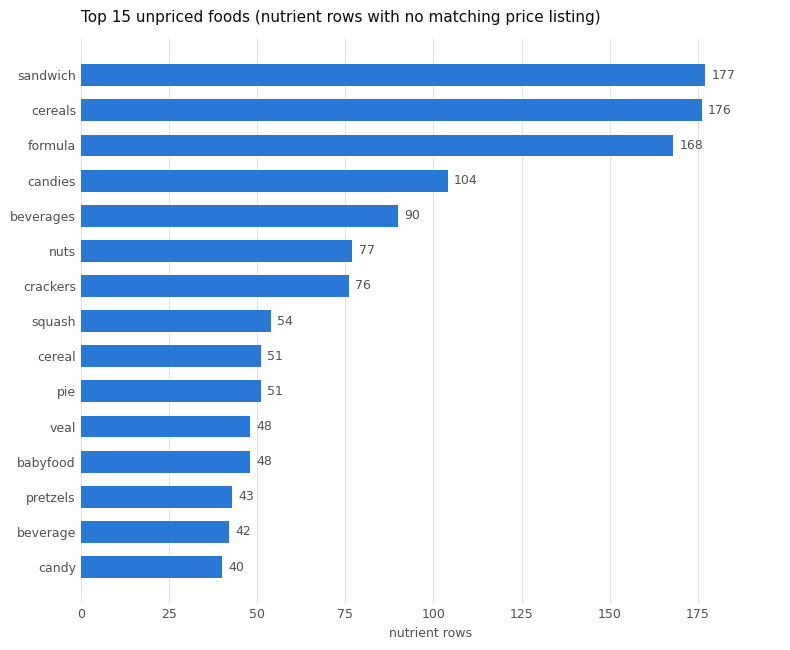

In [26]:
import matplotlib.pyplot as plt

TOP_N = 15
top = unmatched_terms.head(TOP_N)["rows"].iloc[::-1]  # smallest at the bottom of barh

fig, ax = plt.subplots(figsize=(8, 0.36 * len(top) + 1.2))
bars = ax.barh(top.index, top.values, height=0.62, color="#2a78d6")

for bar, value in zip(bars, top.values):
    ax.text(bar.get_width() + max(top.values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{value:,}", va="center", ha="left", fontsize=9, color="#52514e")

ax.set_title(f"Top {TOP_N} unpriced foods (nutrient rows with no matching price listing)",
             loc="left", fontsize=11, color="#0b0b0b", pad=12)
ax.set_xlabel("nutrient rows", fontsize=9, color="#52514e")
ax.tick_params(labelsize=9, colors="#52514e", length=0)
ax.set_xlim(0, max(top.values) * 1.12)
ax.xaxis.grid(True, color="#e5e4e0", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right", "bottom", "left"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

In [27]:
unmatched_terms

,rows
head_term,
sandwich,177
cereals,176
formula,168
candies,104
beverages,90
...,...
lion,1
limeade,1
limas,1


In [28]:
# the whole table, not just the head: one row per head term, most frequent first
unmatched_terms.rename_axis("name").rename(columns={"rows": "occurrences"}).to_csv(
    "data/unmatched_food.csv"
)

**Item-level coverage** — the items of a row are the product spans the NER
extracted, one price each; how many of them can find a price at all. Buckets:
no item priced, at least one item priced, at least half the items priced, every
item priced.

In [29]:
from statistics import median

priced = price_df["matched_key"] != NOT_MATCH

# a matched listing prices the whole span it matched on, not each of its words:
# "cinnamon rolls" is one item, and a roll's price is not the price of cinnamon.
# The median across the listings sharing a key keeps one odd pack size from
# setting it.
span_prices = defaultdict(list)
for key, price in zip(price_df.loc[priced, "matched_key"], price_df.loc[priced, "price_value"]):
    if pd.isna(price):
        continue
    for variant in key_variants(key):
        span_prices[variant].append(float(price))

food_prices = {span: round(median(prices), 2) for span, prices in span_prices.items()}

def price_item(item):
    """The price of the longest suffix of the item some listing reached.

    A suffix for the same reason lookup() takes one: the qualifiers lead
    ("golden layer buttermilk biscuits") and the food itself sits at the end.
    """
    words = item.split()
    for i in range(len(words)):
        price = food_prices.get(" ".join(words[i:]))
        if price is not None:
            return price
    return None

# One row = its extracted product spans; one price per span.
items = nutrient_df["product"]
total_items = items.map(len)
n_rows = len(nutrient_df)

# which spans got a price, and what it is: {"chicken breast": 6.5, "rice": 3.2}
item_prices = items.map(
    lambda spans: {s: p for s in spans if (p := price_item(s)) is not None}
)
count_mapped = item_prices.map(len)
priced_share = (count_mapped / total_items).where(total_items > 0)

# and the other side: the spans of the row no price listing reaches
unpriced_items = [
    [s for s in spans if s not in prices] for spans, prices in zip(items, item_prices)
]

pd.DataFrame(
    [
        ("no item priced", (count_mapped == 0).sum()),
        ("at least one item priced", (count_mapped > 0).sum()),
        ("at least half the items priced", (priced_share >= 0.5).sum()),
        ("every item priced", (priced_share == 1).sum()),
    ],
    columns=["bucket", "rows"],
).assign(pct=lambda d: (d["rows"] / n_rows).map("{:.1%}".format))

,bucket,rows,pct
0,no item priced,3343,25.6%
1,at least one item priced,9740,74.4%
2,at least half the items priced,9471,72.4%
3,every item priced,7452,57.0%


In [30]:
priced_per_row = nutrient_df[["fdc_id", "description"]].assign(
    product=nutrient_df["product"],
    item_prices=item_prices,
    unpriced_items=unpriced_items,
    priced_items=count_mapped,
    total_items=total_items,
    priced_share=priced_share,
)

# Join with additional columns from nutrient
priced_per_row['adj'] = nutrient_df['adj']
priced_per_row['verb'] = nutrient_df['verb']
priced_per_row['total_price'] = (
    priced_per_row['item_prices'].map(lambda p: round(sum(p.values()), 2))
    .where(priced_per_row['priced_share'] == 1, 0)
)
nutrient_columns = ['protein_g','fat_g','carb_g','energy_kcal','fiber_g','sodium_mg','cholesterol_mg','satfat_g','sugars_g']
for nutrient_col in nutrient_columns:
    priced_per_row[nutrient_col] = nutrient_df[nutrient_col]

# drop ones with no item priced
priced_per_row = priced_per_row.loc[priced_per_row["priced_items"] > 0]

priced_per_row.sort_values("priced_share").head(30)

,fdc_id,description,product,item_prices,unpriced_items,priced_items,total_items,priced_share,adj,verb,total_price,protein_g,fat_g,carb_g,energy_kcal,fiber_g,sodium_mg,cholesterol_mg,satfat_g,sugars_g
3722,171363,"Babyfood, cereal, oatmeal, with applesauce and...","[babyfood, cereal, oatmeal, applesauce, bananas]",{'bananas': 4.5},"[babyfood, cereal, oatmeal, applesauce]",1,5,0.200000,[junior],[fortified],0.0,0.89,0.89,16.03,76.0,0.9,4.0,0.0,0.126,8.85
3721,171362,"Babyfood, cereal, oatmeal, with applesauce and...","[babyfood, cereal, oatmeal, applesauce, bananas]",{'bananas': 4.5},"[babyfood, cereal, oatmeal, applesauce]",1,5,0.200000,[],[strained],0.0,0.89,0.89,15.62,75.0,0.9,4.0,0.0,0.125,8.85
6803,174506,"Chicken, broiler, rotisserie, BBQ, back meat only","[chicken, broiler, rotisserie, bbq]",{'chicken': 8.0},"[broiler, rotisserie, bbq]",1,4,0.250000,[],[],0.0,21.85,13.87,0.31,212.0,0.0,563.0,117.0,3.613,0.31
3489,171124,"Chicken, broiler, rotisserie, BBQ, back, meat ...","[chicken, broiler, rotisserie, bbq]",{'chicken': 8.0},"[broiler, rotisserie, bbq]",1,4,0.250000,[],[],0.0,20.29,18.86,0.40,251.0,0.0,509.0,118.0,4.953,0.40
1467,169047,"Babyfood, baked product, finger snacks cereal ...","[babyfood, product, finger snacks, cereal]",{'finger snacks': 9.22},"[babyfood, product, cereal]",1,4,0.250000,[],"[baked, fortified]",0.0,6.40,9.90,76.68,421.0,2.3,0.0,0.0,1.646,28.00
2092,169687,"Snacks, KELLOGG, KELLOGG'S RICE KRISPIES TREAT...","[snacks, rice krispies, treats, squares]",{'snacks': 9.22},"[rice krispies, treats, squares]",1,4,0.250000,[],[],0.0,3.40,9.00,80.50,417.0,0.0,351.0,0.0,1.400,19.36
7163,174880,"Veal, leg, top round, cap off, cutlet, boneles...","[veal, leg, round, cap]",{'leg': 6.8},"[veal, round, cap]",1,4,0.250000,"[top, boneless]","[cooked, grilled]",0.0,31.89,2.63,0.00,151.0,0.0,88.0,72.0,1.012,0.00
3317,170947,"Babyfood, fruit, applesauce and apricots, stra...","[babyfood, fruit, applesauce, apricots]",{'apricots': 6.95},"[babyfood, fruit, applesauce]",1,4,0.250000,[],[strained],0.0,0.20,0.20,11.64,44.0,1.8,0.0,0.0,0.024,9.25
3318,170948,"Babyfood, fruit, applesauce and apricots, junior","[babyfood, fruit, applesauce, apricots]",{'apricots': 6.95},"[babyfood, fruit, applesauce]",1,4,0.250000,[],[],0.0,0.20,0.20,12.40,47.0,1.8,0.0,0.0,0.028,8.72
3319,170949,"Babyfood, fruit, applesauce and cherries, stra...","[babyfood, fruit, applesauce, cherries]",{'cherries': 9.45},"[babyfood, fruit, applesauce]",1,4,0.250000,[],[strained],0.0,0.00,0.00,14.10,51.0,1.1,1.0,0.0,0.000,10.81


In [31]:
priced_per_row.to_csv("data/price_mapped_nutrients.csv", index=False)

**Handled remaining unmatched food**

In [32]:
unmatched_terms

,rows
head_term,
sandwich,177
cereals,176
formula,168
candies,104
beverages,90
...,...
lion,1
limeade,1
limas,1


In [33]:
frequent = unmatched_terms.loc[unmatched_terms["rows"] >= 20]

covered = frequent["rows"].sum()
unmatched_rows = unmatched_terms["rows"].sum()

print(f"terms with >= 20 rows: {len(frequent)}/{len(unmatched_terms)}")
print(f"rows they account for: {covered}/{unmatched_rows} = {covered / unmatched_rows:.1%} of unmatched")
print(f"                       {covered}/{len(nutrient_df)} = {covered / len(nutrient_df):.1%} of all nutrient rows")

terms with >= 20 rows: 29/593
rows they account for: 1607/3266 = 49.2% of unmatched
                       1607/13083 = 12.3% of all nutrient rows
